# ACS Community Context Analysis

**Dataset:** American Community Survey (ACS)  
**Year:** 2024 5-Year Estimates  
**Source:** U.S. Census Bureau  

## Research Role

The ACS adds socioeconomic, household, housing, and demographic context to the pediatric mental health access analysis.

Unlike the NSCH, the ACS does not measure individual children's mental health or whether a specific child received needed care. Instead, it helps identify communities where structural conditions may overlap with the family and socioeconomic risk factors identified in the NSCH analysis.

## Analysis Questions

1. Which states and school districts show the greatest concentration of socioeconomic and household vulnerability?
2. Which ACS indicators align most closely with the risk domains identified in NSCH, particularly poverty, insurance, family conditions, housing, and access to basic resources?
3. Which communities show multiple overlapping vulnerability indicators?
4. Which ACS findings should be carried forward into the cross-dataset community-risk analysis?

In [1]:
import pandas as pd
from pathlib import Path

data_path = Path(
    "../../data/cleaned/ACS_2024_cleaned_state_district.csv"
)

acs = pd.read_csv(data_path)

print("Dataset shape:", acs.shape)
acs.head()

Dataset shape: (10953, 176)


,GEO_ID,NAME,DP02_0003E,DP02_0003PE,DP02_0003PM,DP02_0005E,DP02_0005PE,DP02_0005PM,DP02_0007E,DP02_0007PE,...,DP05_0075E,DP05_0075PE,DP05_0075PM,DP05_0090E,DP05_0090PE,DP05_0090PM,DP05_0095E,DP05_0095PE,DP05_0095PM,FIPSST
0,0400000US01,Alabama,325534.0,16.3,0.2,35399.0,1.8,0.1,20605.0,1.0,...,270559,5.3,0.1,284135,5.6,0.1,4802633,94.4,0.1,1
1,0400000US02,Alaska,53341.0,19.7,0.5,8142.0,3.0,0.2,4333.0,1.6,...,99890,13.6,0.5,53803,7.3,0.1,681903,92.7,0.1,2
2,0400000US04,Arizona,477403.0,16.7,0.2,77389.0,2.7,0.1,38148.0,1.3,...,1441985,19.5,0.2,2313806,31.4,*****,5065032,68.6,*****,4
3,0400000US05,Arkansas,213116.0,17.7,0.3,26327.0,2.2,0.1,16104.0,1.3,...,315183,10.3,0.2,275571,9.0,0.1,2773820,91.0,0.1,5
4,0400000US06,California,2703186.0,20.0,0.1,360079.0,2.7,0.1,168186.0,1.2,...,7536798,19.2,0.1,15778963,40.2,*****,23508414,59.8,*****,6


In [2]:
# Identify ACS geographic level from GEO_ID

acs["geography_level"] = acs["GEO_ID"].astype(str).apply(
    lambda x: "State" if "0400000US" in x else
              "School District" if "9700000US" in x else
              "Other"
)

print(acs["geography_level"].value_counts())

geography_level
School District    10901
State                 52
Name: count, dtype: int64


## Geographic Scope

The cleaned ACS dataset contains both state-level and school-district-level records.

- 52 state-level records
- 10,901 school-district-level records

State-level data will be used to establish broad geographic context, while school-district-level data will provide the primary community-level detail for identifying areas with overlapping socioeconomic and household vulnerability.

In [3]:
# Show retained ACS variables by profile

profile_counts = {
    "DP02 - Social Characteristics": sum(col.startswith("DP02") for col in acs.columns),
    "DP03 - Economic Characteristics": sum(col.startswith("DP03") for col in acs.columns),
    "DP04 - Housing Characteristics": sum(col.startswith("DP04") for col in acs.columns),
    "DP05 - Demographic Characteristics": sum(col.startswith("DP05") for col in acs.columns)
}

pd.Series(profile_counts, name="Number of Columns")

DP02 - Social Characteristics         48
DP03 - Economic Characteristics       31
DP04 - Housing Characteristics        44
DP05 - Demographic Characteristics    47
Name: Number of Columns, dtype: int64

In [4]:
# Show the percentage variables retained from each ACS profile

for profile in ["DP02", "DP03", "DP04", "DP05"]:
    print(f"\n{profile} percentage variables:")
    
    cols = [
        col for col in acs.columns
        if col.startswith(profile) and col.endswith("PE")
    ]
    
    print(cols)


DP02 percentage variables:
['DP02_0003PE', 'DP02_0005PE', 'DP02_0007PE', 'DP02_0011PE', 'DP02_0014PE', 'DP02_0056PE', 'DP02_0057PE', 'DP02_0067PE', 'DP02_0068PE', 'DP02_0073PE', 'DP02_0074PE', 'DP02_0113PE', 'DP02_0114PE', 'DP02_0115PE', 'DP02_0153PE', 'DP02_0154PE']

DP03 percentage variables:
['DP03_0016PE', 'DP03_0017PE', 'DP03_0072PE', 'DP03_0074PE', 'DP03_0100PE', 'DP03_0101PE', 'DP03_0120PE', 'DP03_0129PE', 'DP03_0132PE']

DP04 percentage variables:
['DP04_0046PE', 'DP04_0047PE', 'DP04_0058PE', 'DP04_0059PE', 'DP04_0060PE', 'DP04_0061PE', 'DP04_0073PE', 'DP04_0074PE', 'DP04_0078PE', 'DP04_0079PE', 'DP04_0114PE', 'DP04_0115PE', 'DP04_0141PE', 'DP04_0142PE']

DP05 percentage variables:
['DP05_0002PE', 'DP05_0003PE', 'DP05_0006PE', 'DP05_0007PE', 'DP05_0008PE', 'DP05_0019PE', 'DP05_0037PE', 'DP05_0045PE', 'DP05_0053PE', 'DP05_0061PE', 'DP05_0069PE', 'DP05_0074PE', 'DP05_0075PE', 'DP05_0090PE', 'DP05_0095PE']


## Focused Community Vulnerability Indicators

The ACS contains a much broader set of social, economic, housing, and demographic measures than is needed for this analysis.

Based on the NSCH findings and the project research questions, the ACS analysis will focus on community-level indicators related to:

- child poverty
- health insurance access
- household and caregiver structure
- economic strain
- housing burden
- transportation access
- broadband access
- language access

These measures do not identify whether an individual child has an unmet mental health need. Instead, they provide community-level context that can be combined later with school-resource and provider-shortage data.

In [5]:
# Create focused ACS community indicators

acs_indicators = acs[
    [
        "GEO_ID",
        "NAME",
        "FIPSST",
        "geography_level",

        # Family / household context
        "DP02_0011PE",

        # Language access
        "DP02_0115PE",

        # Digital access
        "DP02_0154PE",

        # Economic / insurance
        "DP03_0074PE",
        "DP03_0101PE",
        "DP03_0129PE",
        "DP03_0132PE",

        # Housing
        "DP04_0047PE",
        "DP04_0115PE",
        "DP04_0142PE",

        # Transportation
        "pct_has_vehicle"
    ]
].copy()

acs_indicators = acs_indicators.rename(
    columns={
        "DP02_0011PE": "female_householder_with_children_pct",
        "DP02_0115PE": "limited_english_pct",
        "DP02_0154PE": "broadband_access_pct",

        "DP03_0074PE": "snap_households_pct",
        "DP03_0101PE": "uninsured_under19_pct",
        "DP03_0129PE": "child_poverty_under18_pct",
        "DP03_0132PE": "child_poverty_age5_17_pct",

        "DP04_0047PE": "renter_occupied_pct",
        "DP04_0115PE": "owner_cost_burden_35plus_pct",
        "DP04_0142PE": "rent_burden_35plus_pct"
    }
)

acs_indicators.head()

,GEO_ID,NAME,FIPSST,geography_level,female_householder_with_children_pct,limited_english_pct,broadband_access_pct,snap_households_pct,uninsured_under19_pct,child_poverty_under18_pct,child_poverty_age5_17_pct,renter_occupied_pct,owner_cost_burden_35plus_pct,rent_burden_35plus_pct,pct_has_vehicle
0,0400000US01,Alabama,1,State,6.0,2.4,87.5,13.7,3.6,21.3,19.9,29.8,18.2,39.9,94.6
1,0400000US02,Alaska,2,State,4.0,4.2,91.9,10.1,8.0,12.2,10.6,33.2,21.1,35.1,91.0
2,0400000US04,Arizona,4,State,4.4,8.0,91.5,10.4,8.8,16.2,15.3,32.6,21.1,42.2,94.6
3,0400000US05,Arkansas,5,State,5.6,3.4,86.7,10.2,6.0,21.1,19.5,33.6,16.9,35.9,94.1
4,0400000US06,California,6,State,4.5,17.5,93.5,12.4,3.2,15.0,14.7,44.1,30.0,46.0,92.9


In [6]:
# Check data types and missing values for focused indicators

indicator_cols = [
    "female_householder_with_children_pct",
    "limited_english_pct",
    "broadband_access_pct",
    "snap_households_pct",
    "uninsured_under19_pct",
    "child_poverty_under18_pct",
    "child_poverty_age5_17_pct",
    "renter_occupied_pct",
    "owner_cost_burden_35plus_pct",
    "rent_burden_35plus_pct",
    "pct_has_vehicle"
]

for col in indicator_cols:
    acs_indicators[col] = pd.to_numeric(
        acs_indicators[col],
        errors="coerce"
    )

summary = pd.DataFrame({
    "Missing": acs_indicators[indicator_cols].isna().sum(),
    "Valid": acs_indicators[indicator_cols].notna().sum()
})

summary

,Missing,Valid
female_householder_with_children_pct,14,10939
limited_english_pct,14,10939
broadband_access_pct,14,10939
snap_households_pct,12,10941
uninsured_under19_pct,32,10921
child_poverty_under18_pct,36,10917
child_poverty_age5_17_pct,44,10909
renter_occupied_pct,12,10941
owner_cost_burden_35plus_pct,41,10912
rent_burden_35plus_pct,62,10891


## State-Level Community Vulnerability Baseline

State-level ACS records provide a broad baseline for comparing economic, household, insurance, housing, transportation, and digital-access conditions.

These state comparisons are not used to infer individual mental health outcomes. Instead, they establish broad geographic context before examining school-district-level variation.

In [7]:
# Separate state and district records

acs_states = acs_indicators[
    acs_indicators["geography_level"] == "State"
].copy()

acs_districts = acs_indicators[
    acs_indicators["geography_level"] == "School District"
].copy()

print("State records:", len(acs_states))
print("District records:", len(acs_districts))

State records: 52
District records: 10901


In [8]:
state_summary_cols = [
    "child_poverty_under18_pct",
    "uninsured_under19_pct",
    "snap_households_pct",
    "female_householder_with_children_pct",
    "limited_english_pct",
    "broadband_access_pct",
    "owner_cost_burden_35plus_pct",
    "rent_burden_35plus_pct",
    "pct_has_vehicle"
]

state_summary = (
    acs_states[state_summary_cols]
    .describe()
    .T[
        ["mean", "50%", "min", "max"]
    ]
    .rename(
        columns={
            "mean": "Mean",
            "50%": "Median",
            "min": "Minimum",
            "max": "Maximum"
        }
    )
    .round(1)
)

state_summary

,Mean,Median,Minimum,Maximum
child_poverty_under18_pct,16.2,15.0,7.9,54.9
uninsured_under19_pct,5.0,4.8,1.6,12.0
snap_households_pct,12.0,11.4,5.2,47.4
female_householder_with_children_pct,4.6,4.6,3.0,7.6
limited_english_pct,5.7,4.8,0.7,17.5
broadband_access_pct,90.4,90.7,84.1,93.6
owner_cost_burden_35plus_pct,20.3,20.1,14.6,31.7
rent_burden_35plus_pct,39.6,39.4,30.4,50.2
pct_has_vehicle,92.2,93.8,64.0,96.3


In [9]:
def top_states(indicator, n=10):
    return (
        acs_states[
            ["NAME", indicator]
        ]
        .dropna()
        .sort_values(
            indicator,
            ascending=False
        )
        .head(n)
        .reset_index(drop=True)
    )

print("Highest child poverty:")
display(
    top_states(
        "child_poverty_under18_pct"
    )
)

print("\nHighest uninsured rate under age 19:")
display(
    top_states(
        "uninsured_under19_pct"
    )
)

print("\nHighest SNAP household rate:")
display(
    top_states(
        "snap_households_pct"
    )
)

print("\nHighest rent burden:")
display(
    top_states(
        "rent_burden_35plus_pct"
    )
)

Highest child poverty:


,NAME,child_poverty_under18_pct
0,Puerto Rico,54.9
1,Mississippi,26.0
2,Louisiana,25.4
3,New Mexico,24.0
4,District of Columbia,22.8
5,West Virginia,21.5
6,Alabama,21.3
7,Arkansas,21.1
8,Kentucky,20.3
9,Oklahoma,20.1



Highest uninsured rate under age 19:


,NAME,uninsured_under19_pct
0,Texas,12.0
1,Wyoming,9.1
2,Arizona,8.8
3,Oklahoma,8.3
4,Nevada,8.0
5,Alaska,8.0
6,Florida,7.5
7,South Dakota,7.3
8,Montana,7.1
9,Georgia,6.9



Highest SNAP household rate:


,NAME,snap_households_pct
0,Puerto Rico,47.4
1,New Mexico,19.2
2,West Virginia,17.3
3,Louisiana,17.3
4,Oregon,16.0
5,New York,15.6
6,Massachusetts,14.7
7,Pennsylvania,14.4
8,District of Columbia,14.3
9,Oklahoma,14.1



Highest rent burden:


,NAME,rent_burden_35plus_pct
0,Florida,50.2
1,Nevada,46.4
2,Louisiana,46.3
3,Hawaii,46.2
4,California,46.0
5,Connecticut,43.5
6,Georgia,43.4
7,Oregon,43.1
8,New York,43.1
9,South Carolina,42.8


## District-Level Overlapping Vulnerability

State averages can conceal substantial differences between local communities. The school-district records are therefore used to identify areas where multiple socioeconomic and access-related vulnerabilities occur simultaneously.

Rather than treating any single ACS measure as a proxy for mental health need, this analysis identifies districts that fall into relatively high-risk ranges across several indicators.

A district receives one vulnerability flag for each of the following conditions:

- child poverty in the highest 25% of districts
- uninsured youth in the highest 25%
- SNAP participation in the highest 25%
- female-householder households with children in the highest 25%
- housing cost burden in the highest 25%
- limited English proficiency in the highest 25%
- broadband access in the lowest 25%
- vehicle access in the lowest 25%

The total number of flags is used as an exploratory measure of overlapping community vulnerability. It is not a validated clinical risk score.

In [10]:
# Create district-level vulnerability flags

district_risk = acs_districts.copy()

high_risk_indicators = [
    "child_poverty_under18_pct",
    "uninsured_under19_pct",
    "snap_households_pct",
    "female_householder_with_children_pct",
    "limited_english_pct",
    "rent_burden_35plus_pct"
]

low_access_indicators = [
    "broadband_access_pct",
    "pct_has_vehicle"
]

# Highest quartile = vulnerability
for col in high_risk_indicators:
    cutoff = district_risk[col].quantile(0.75)
    district_risk[f"{col}_flag"] = (
        district_risk[col] >= cutoff
    ).astype(int)

# Lowest quartile = vulnerability
for col in low_access_indicators:
    cutoff = district_risk[col].quantile(0.25)
    district_risk[f"{col}_flag"] = (
        district_risk[col] <= cutoff
    ).astype(int)

flag_cols = [
    col for col in district_risk.columns
    if col.endswith("_flag")
]

district_risk["vulnerability_flags"] = (
    district_risk[flag_cols].sum(axis=1)
)

district_risk["vulnerability_flags"].value_counts().sort_index()

vulnerability_flags
0    2479
1    2702
2    2085
3    1378
4     984
5     732
6     405
7     117
8      19
Name: count, dtype: int64

In [11]:
# Districts with the greatest number of overlapping vulnerability flags

top_vulnerable_districts = (
    district_risk[
        [
            "NAME",
            "FIPSST",
            "vulnerability_flags",
            "child_poverty_under18_pct",
            "uninsured_under19_pct",
            "snap_households_pct",
            "female_householder_with_children_pct",
            "limited_english_pct",
            "broadband_access_pct",
            "rent_burden_35plus_pct",
            "pct_has_vehicle"
        ]
    ]
    .sort_values(
        [
            "vulnerability_flags",
            "child_poverty_under18_pct"
        ],
        ascending=[False, False]
    )
    .head(25)
    .reset_index(drop=True)
)

top_vulnerable_districts

,NAME,FIPSST,vulnerability_flags,child_poverty_under18_pct,uninsured_under19_pct,snap_households_pct,female_householder_with_children_pct,limited_english_pct,broadband_access_pct,rent_burden_35plus_pct,pct_has_vehicle
0,"San Diego Independent School District, Texas",48,8,53.6,22.8,28.0,17.5,7.9,66.0,44.4,88.4
1,"West Oso Independent School District, Texas",48,8,53.5,10.3,29.9,9.4,6.6,72.5,62.5,87.6
2,"Alice Independent School District, Texas",48,8,49.9,12.8,25.8,15.0,9.3,73.8,60.6,91.7
3,"East Cleveland City School District, Ohio",39,8,49.1,7.7,44.3,10.5,4.7,76.2,50.3,68.2
4,"Santa Maria Independent School District, Texas",48,8,48.5,10.9,35.3,14.2,38.8,66.1,48.1,87.0
5,"Buckholts Independent School District, Texas",48,8,48.0,12.4,28.1,8.5,10.8,66.9,53.1,91.5
6,"Laredo Independent School District, Texas",48,8,47.3,14.6,36.4,13.2,50.5,76.8,46.8,85.7
7,"Roma Independent School District, Texas",48,8,45.5,15.7,47.8,14.5,38.9,73.5,51.2,87.3
8,San Benito Consolidated Independent School Dis...,48,8,44.1,15.8,30.2,10.5,24.7,80.8,44.5,92.8
9,"Mathis Independent School District, Texas",48,8,42.4,11.4,19.2,5.3,7.3,72.7,43.5,88.4


## District-Level Overlapping Vulnerability

State-level averages provide broad geographic context, but they can hide substantial variation between local communities.

The school-district records are therefore used to identify communities where several socioeconomic and access-related vulnerabilities occur at the same time.

This exploratory analysis uses relative district-level thresholds rather than treating any single ACS measure as a direct indicator of mental health need.

A district receives one vulnerability flag when it falls:

- in the highest 25% for child poverty
- in the highest 25% for uninsured youth
- in the highest 25% for SNAP participation
- in the highest 25% for female-householder households with children
- in the highest 25% for limited English proficiency
- in the highest 25% for rent burden
- in the lowest 25% for broadband access
- in the lowest 25% for vehicle access

The total number of flags represents overlapping community vulnerability. This is an exploratory contextual measure, not a validated clinical risk score.

In [12]:
# Create district-level vulnerability flags

district_risk = acs_districts.copy()

high_risk_indicators = [
    "child_poverty_under18_pct",
    "uninsured_under19_pct",
    "snap_households_pct",
    "female_householder_with_children_pct",
    "limited_english_pct",
    "rent_burden_35plus_pct"
]

low_access_indicators = [
    "broadband_access_pct",
    "pct_has_vehicle"
]

# Highest quartile = vulnerability
for col in high_risk_indicators:
    cutoff = district_risk[col].quantile(0.75)

    district_risk[f"{col}_flag"] = (
        district_risk[col] >= cutoff
    ).astype(int)

# Lowest quartile = vulnerability
for col in low_access_indicators:
    cutoff = district_risk[col].quantile(0.25)

    district_risk[f"{col}_flag"] = (
        district_risk[col] <= cutoff
    ).astype(int)

flag_cols = [
    col for col in district_risk.columns
    if col.endswith("_flag")
]

district_risk["vulnerability_flags"] = (
    district_risk[flag_cols].sum(axis=1)
)

flag_distribution = (
    district_risk["vulnerability_flags"]
    .value_counts()
    .sort_index()
    .rename_axis("Number of Vulnerability Flags")
    .reset_index(name="Districts")
)

flag_distribution["Percent of Districts"] = (
    flag_distribution["Districts"]
    / len(district_risk)
    * 100
).round(1)

flag_distribution

,Number of Vulnerability Flags,Districts,Percent of Districts
0,0,2479,22.7
1,1,2702,24.8
2,2,2085,19.1
3,3,1378,12.6
4,4,984,9.0
5,5,732,6.7
6,6,405,3.7
7,7,117,1.1
8,8,19,0.2


### Finding: Overlapping Community Vulnerability

Most school districts did not fall into the highest-risk range across many indicators at once, but substantial overlap was still present.

Approximately 21.6% of districts had four or more vulnerability flags, while about 5.0% had six or more.

Only 19 districts, approximately 0.2% of all districts, met the vulnerability threshold for all eight indicators.

This distribution suggests that community vulnerability is concentrated rather than evenly distributed across school districts. The vulnerability flag count is used as an exploratory way to identify communities where several socioeconomic and access-related pressures overlap.

In [13]:
# Examine districts with the greatest overlapping vulnerability

top_vulnerable_districts = (
    district_risk[
        [
            "NAME",
            "FIPSST",
            "vulnerability_flags",
            "child_poverty_under18_pct",
            "uninsured_under19_pct",
            "snap_households_pct",
            "female_householder_with_children_pct",
            "limited_english_pct",
            "broadband_access_pct",
            "rent_burden_35plus_pct",
            "pct_has_vehicle"
        ]
    ]
    .sort_values(
        [
            "vulnerability_flags",
            "child_poverty_under18_pct"
        ],
        ascending=[False, False]
    )
    .head(30)
    .reset_index(drop=True)
)

top_vulnerable_districts

,NAME,FIPSST,vulnerability_flags,child_poverty_under18_pct,uninsured_under19_pct,snap_households_pct,female_householder_with_children_pct,limited_english_pct,broadband_access_pct,rent_burden_35plus_pct,pct_has_vehicle
0,"San Diego Independent School District, Texas",48,8,53.6,22.8,28.0,17.5,7.9,66.0,44.4,88.4
1,"West Oso Independent School District, Texas",48,8,53.5,10.3,29.9,9.4,6.6,72.5,62.5,87.6
2,"Alice Independent School District, Texas",48,8,49.9,12.8,25.8,15.0,9.3,73.8,60.6,91.7
3,"East Cleveland City School District, Ohio",39,8,49.1,7.7,44.3,10.5,4.7,76.2,50.3,68.2
4,"Santa Maria Independent School District, Texas",48,8,48.5,10.9,35.3,14.2,38.8,66.1,48.1,87.0
5,"Buckholts Independent School District, Texas",48,8,48.0,12.4,28.1,8.5,10.8,66.9,53.1,91.5
6,"Laredo Independent School District, Texas",48,8,47.3,14.6,36.4,13.2,50.5,76.8,46.8,85.7
7,"Roma Independent School District, Texas",48,8,45.5,15.7,47.8,14.5,38.9,73.5,51.2,87.3
8,San Benito Consolidated Independent School Dis...,48,8,44.1,15.8,30.2,10.5,24.7,80.8,44.5,92.8
9,"Mathis Independent School District, Texas",48,8,42.4,11.4,19.2,5.3,7.3,72.7,43.5,88.4


In [14]:
# Add state/territory names from FIPS codes

state_fips_names = {
    1: "Alabama", 2: "Alaska", 4: "Arizona", 5: "Arkansas",
    6: "California", 8: "Colorado", 9: "Connecticut",
    10: "Delaware", 11: "District of Columbia", 12: "Florida",
    13: "Georgia", 15: "Hawaii", 16: "Idaho", 17: "Illinois",
    18: "Indiana", 19: "Iowa", 20: "Kansas", 21: "Kentucky",
    22: "Louisiana", 23: "Maine", 24: "Maryland",
    25: "Massachusetts", 26: "Michigan", 27: "Minnesota",
    28: "Mississippi", 29: "Missouri", 30: "Montana",
    31: "Nebraska", 32: "Nevada", 33: "New Hampshire",
    34: "New Jersey", 35: "New Mexico", 36: "New York",
    37: "North Carolina", 38: "North Dakota", 39: "Ohio",
    40: "Oklahoma", 41: "Oregon", 42: "Pennsylvania",
    44: "Rhode Island", 45: "South Carolina",
    46: "South Dakota", 47: "Tennessee", 48: "Texas",
    49: "Utah", 50: "Vermont", 51: "Virginia",
    53: "Washington", 54: "West Virginia", 55: "Wisconsin",
    56: "Wyoming", 72: "Puerto Rico"
}

top_vulnerable_districts["State/Territory"] = (
    top_vulnerable_districts["FIPSST"]
    .map(state_fips_names)
)

top_vulnerable_districts[
    [
        "NAME",
        "State/Territory",
        "vulnerability_flags",
        "child_poverty_under18_pct",
        "uninsured_under19_pct",
        "snap_households_pct",
        "broadband_access_pct",
        "rent_burden_35plus_pct",
        "pct_has_vehicle"
    ]
]

,NAME,State/Territory,vulnerability_flags,child_poverty_under18_pct,uninsured_under19_pct,snap_households_pct,broadband_access_pct,rent_burden_35plus_pct,pct_has_vehicle
0,"San Diego Independent School District, Texas",Texas,8,53.6,22.8,28.0,66.0,44.4,88.4
1,"West Oso Independent School District, Texas",Texas,8,53.5,10.3,29.9,72.5,62.5,87.6
2,"Alice Independent School District, Texas",Texas,8,49.9,12.8,25.8,73.8,60.6,91.7
3,"East Cleveland City School District, Ohio",Ohio,8,49.1,7.7,44.3,76.2,50.3,68.2
4,"Santa Maria Independent School District, Texas",Texas,8,48.5,10.9,35.3,66.1,48.1,87.0
5,"Buckholts Independent School District, Texas",Texas,8,48.0,12.4,28.1,66.9,53.1,91.5
6,"Laredo Independent School District, Texas",Texas,8,47.3,14.6,36.4,76.8,46.8,85.7
7,"Roma Independent School District, Texas",Texas,8,45.5,15.7,47.8,73.5,51.2,87.3
8,San Benito Consolidated Independent School Dis...,Texas,8,44.1,15.8,30.2,80.8,44.5,92.8
9,"Mathis Independent School District, Texas",Texas,8,42.4,11.4,19.2,72.7,43.5,88.4


## Exploratory Data Analysis: District Vulnerability

The following visualizations examine how vulnerability is distributed across school districts and how the underlying ACS indicators relate to one another.

Because the ACS indicators are continuous percentages, correlation analysis is appropriate for examining whether community-level socioeconomic and access conditions tend to occur together.

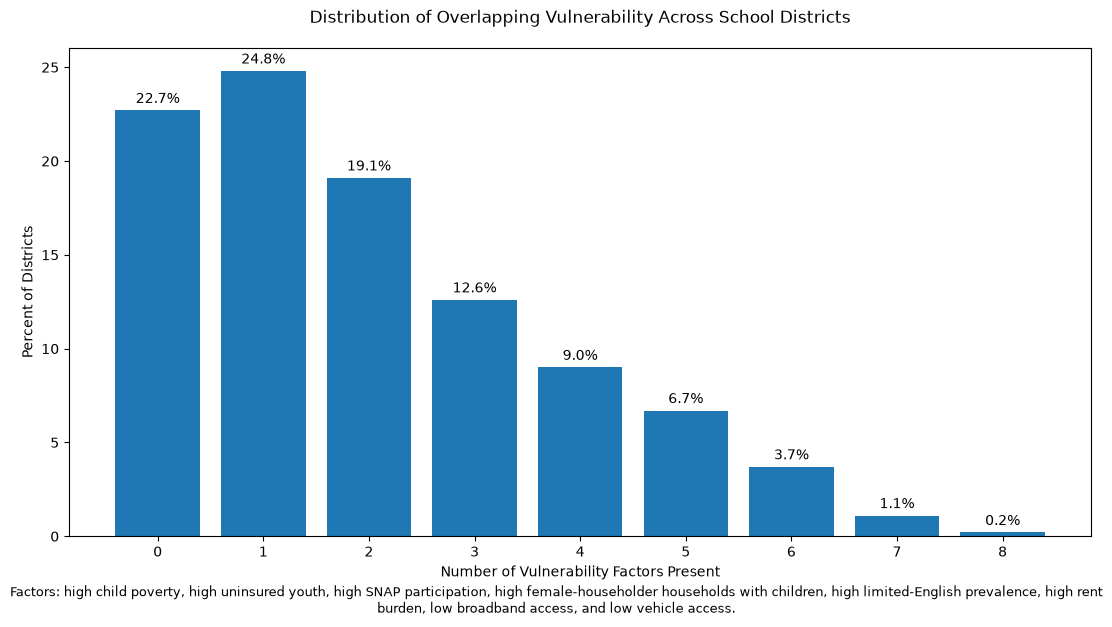

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

bars = plt.bar(
    flag_distribution["Number of Vulnerability Flags"].astype(str),
    flag_distribution["Percent of Districts"]
)

plt.title(
    "Distribution of Overlapping Vulnerability Across School Districts",
    pad=18
)

plt.xlabel("Number of Vulnerability Factors Present")
plt.ylabel("Percent of Districts")

for bar, value in zip(
    bars,
    flag_distribution["Percent of Districts"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{value:.1f}%",
        ha="center"
    )

factor_note = (
    "Factors: high child poverty, high uninsured youth, high SNAP participation, "
    "high female-householder households with children, high limited-English prevalence, "
    "high rent burden, low broadband access, and low vehicle access."
)

plt.figtext(
    0.5,
    -0.03,
    factor_note,
    ha="center",
    wrap=True,
    fontsize=9
)

plt.tight_layout()
plt.show()

### Finding: Distribution of Overlapping Vulnerability

Nearly half of school districts had zero or one vulnerability flag, while approximately 21.6% had four or more.

A smaller group of districts showed especially concentrated vulnerability: approximately 5.0% had six or more flags, and 19 districts met all eight thresholds.

This indicates that socioeconomic and access-related vulnerability is unevenly distributed across school districts.

In [17]:
correlation_cols = [
    "child_poverty_under18_pct",
    "uninsured_under19_pct",
    "snap_households_pct",
    "female_householder_with_children_pct",
    "limited_english_pct",
    "broadband_access_pct",
    "rent_burden_35plus_pct",
    "pct_has_vehicle"
]

district_correlations = (
    district_risk[correlation_cols]
    .corr()
    .round(2)
)

district_correlations

,child_poverty_under18_pct,uninsured_under19_pct,snap_households_pct,female_householder_with_children_pct,limited_english_pct,broadband_access_pct,rent_burden_35plus_pct,pct_has_vehicle
child_poverty_under18_pct,1.00,0.14,0.64,0.45,0.12,-0.40,0.17,-0.34
uninsured_under19_pct,0.14,1.00,0.04,0.02,0.17,-0.26,-0.08,-0.12
snap_households_pct,0.64,0.04,1.00,0.51,0.17,-0.40,0.17,-0.47
female_householder_with_children_pct,0.45,0.02,0.51,1.00,0.24,-0.11,0.19,-0.29
limited_english_pct,0.12,0.17,0.17,0.24,1.00,0.05,0.14,-0.20
broadband_access_pct,-0.40,-0.26,-0.40,-0.11,0.05,1.00,0.11,0.25
rent_burden_35plus_pct,0.17,-0.08,0.17,0.19,0.14,0.11,1.00,-0.12
pct_has_vehicle,-0.34,-0.12,-0.47,-0.29,-0.20,0.25,-0.12,1.00


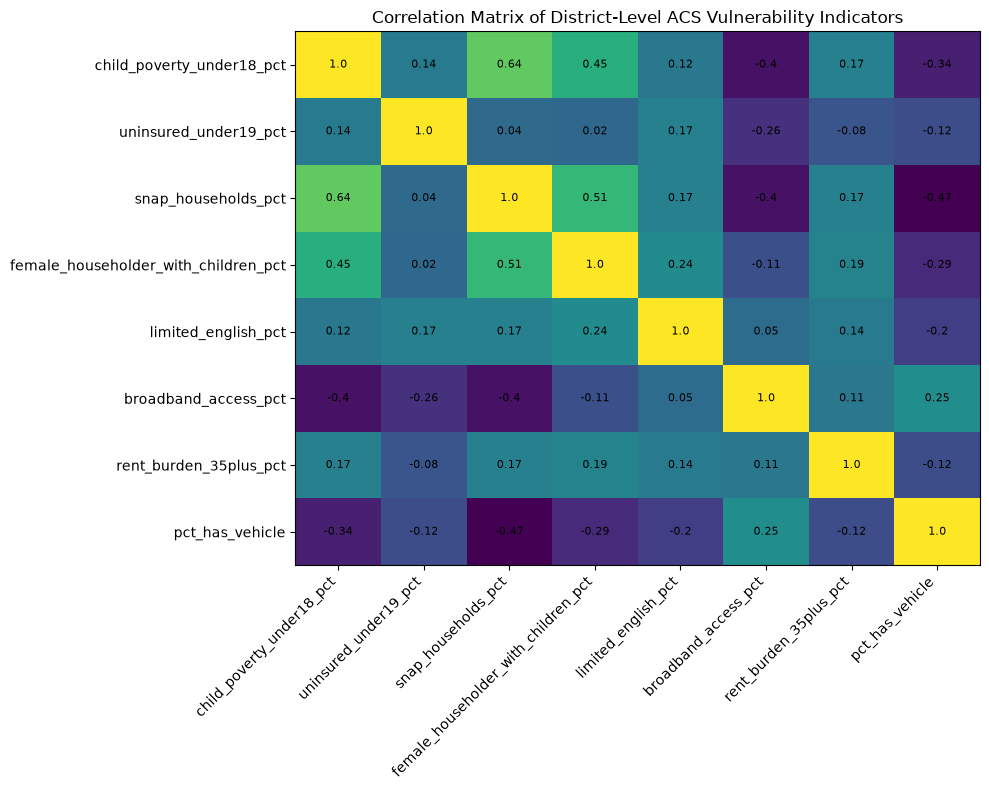

In [18]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 8))

matrix = ax.imshow(
    district_correlations,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(district_correlations.columns))
)

ax.set_yticks(
    np.arange(len(district_correlations.index))
)

ax.set_xticklabels(
    district_correlations.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    district_correlations.index
)

for i in range(len(district_correlations.index)):
    for j in range(len(district_correlations.columns)):
        ax.text(
            j,
            i,
            district_correlations.iloc[i, j],
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix of District-Level ACS Vulnerability Indicators")
plt.tight_layout()
plt.show()

### Finding: Relationships Between Community Vulnerability Indicators

The correlation analysis showed that several district-level socioeconomic vulnerability indicators tend to occur together.

The strongest positive relationship was between child poverty and SNAP participation (`r = 0.64`). SNAP participation was also moderately associated with female-householder households with children (`r = 0.51`), while child poverty was moderately associated with female-householder households with children (`r = 0.45`).

Access-related measures showed inverse relationships with economic vulnerability. SNAP participation was negatively correlated with vehicle access (`r = -0.47`), while both child poverty and SNAP participation were negatively correlated with broadband access (`r = -0.40`).

Most other relationships were weak, indicating that the indicators represent related but distinct dimensions of community vulnerability rather than a single underlying condition.

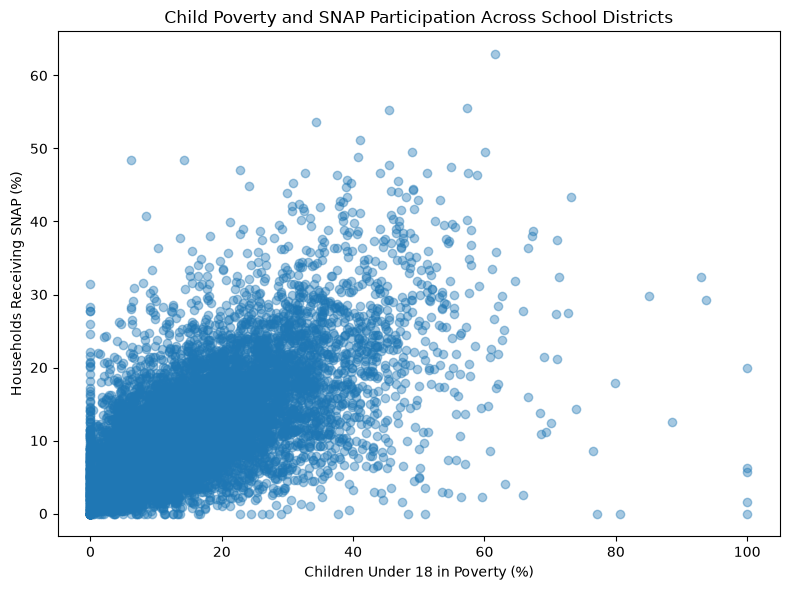

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    district_risk["child_poverty_under18_pct"],
    district_risk["snap_households_pct"],
    alpha=0.4
)

plt.title("Child Poverty and SNAP Participation Across School Districts")
plt.xlabel("Children Under 18 in Poverty (%)")
plt.ylabel("Households Receiving SNAP (%)")

plt.tight_layout()
plt.show()

### Finding: Child Poverty and SNAP Participation

School districts with higher child poverty rates generally also had higher rates of households receiving SNAP benefits.

The correlation between the two measures was `r = 0.64`, the strongest relationship among the ACS vulnerability indicators examined.

The relationship is substantial but not perfect, reinforcing the decision to examine multiple community indicators rather than using poverty alone to define vulnerability.

## Geographic Concentration of High-Vulnerability Districts

To identify where overlapping vulnerability is concentrated geographically, districts with four or more vulnerability flags are classified as high-vulnerability districts.

The analysis then calculates the percentage of districts within each state or territory that meet this threshold.

In [20]:
# Flag districts with 4 or more overlapping vulnerability factors

district_risk["high_vulnerability"] = (
    district_risk["vulnerability_flags"] >= 4
).astype(int)

# Add state/territory names

state_fips_names = {
    1: "Alabama", 2: "Alaska", 4: "Arizona", 5: "Arkansas",
    6: "California", 8: "Colorado", 9: "Connecticut",
    10: "Delaware", 11: "District of Columbia", 12: "Florida",
    13: "Georgia", 15: "Hawaii", 16: "Idaho", 17: "Illinois",
    18: "Indiana", 19: "Iowa", 20: "Kansas", 21: "Kentucky",
    22: "Louisiana", 23: "Maine", 24: "Maryland",
    25: "Massachusetts", 26: "Michigan", 27: "Minnesota",
    28: "Mississippi", 29: "Missouri", 30: "Montana",
    31: "Nebraska", 32: "Nevada", 33: "New Hampshire",
    34: "New Jersey", 35: "New Mexico", 36: "New York",
    37: "North Carolina", 38: "North Dakota", 39: "Ohio",
    40: "Oklahoma", 41: "Oregon", 42: "Pennsylvania",
    44: "Rhode Island", 45: "South Carolina",
    46: "South Dakota", 47: "Tennessee", 48: "Texas",
    49: "Utah", 50: "Vermont", 51: "Virginia",
    53: "Washington", 54: "West Virginia", 55: "Wisconsin",
    56: "Wyoming", 72: "Puerto Rico"
}

district_risk["State/Territory"] = (
    district_risk["FIPSST"].map(state_fips_names)
)

state_vulnerability = (
    district_risk
    .groupby("State/Territory", observed=False)
    .agg(
        Total_Districts=("high_vulnerability", "size"),
        High_Vulnerability_Districts=("high_vulnerability", "sum")
    )
    .reset_index()
)

state_vulnerability["Percent_High_Vulnerability"] = (
    state_vulnerability["High_Vulnerability_Districts"]
    / state_vulnerability["Total_Districts"]
    * 100
).round(1)

state_vulnerability = (
    state_vulnerability
    .sort_values(
        "Percent_High_Vulnerability",
        ascending=False
    )
    .reset_index(drop=True)
)

state_vulnerability.head(15)

,State/Territory,Total_Districts,High_Vulnerability_Districts,Percent_High_Vulnerability
0,District of Columbia,1,1,100.0
1,Louisiana,69,48,69.6
2,New Mexico,89,54,60.7
3,Mississippi,137,77,56.2
4,Georgia,182,98,53.8
5,Alaska,53,26,49.1
6,Alabama,141,59,41.8
7,South Carolina,74,30,40.5
8,North Carolina,118,44,37.3
9,Texas,1018,371,36.4


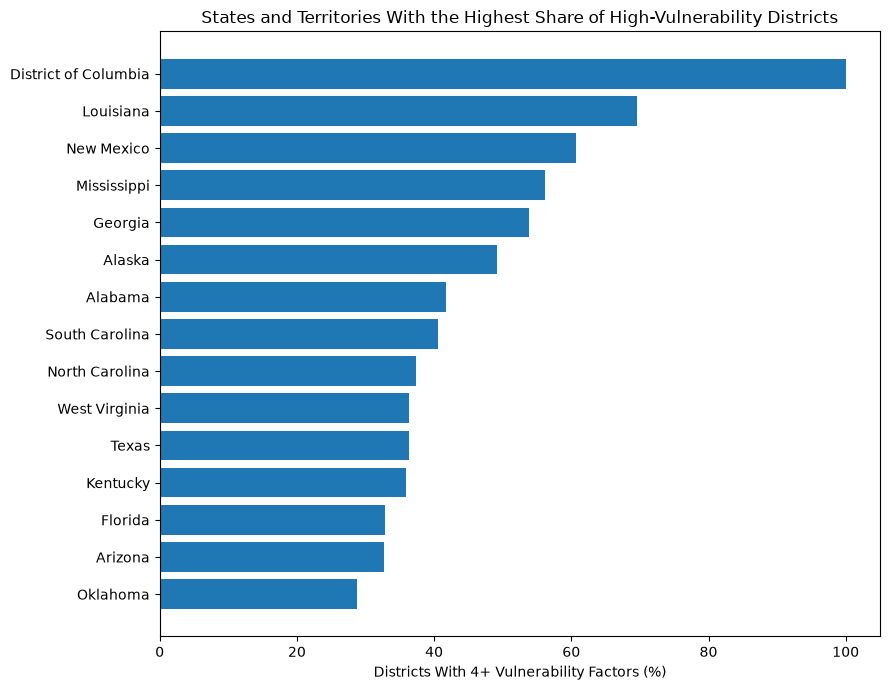

In [21]:
top_state_vulnerability = state_vulnerability.head(15).sort_values(
    "Percent_High_Vulnerability"
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_state_vulnerability["State/Territory"],
    top_state_vulnerability["Percent_High_Vulnerability"]
)

plt.title(
    "States and Territories With the Highest Share of High-Vulnerability Districts"
)

plt.xlabel("Districts With 4+ Vulnerability Factors (%)")
plt.ylabel("")

plt.tight_layout()
plt.show()

### Finding: Geographic Concentration of High-Vulnerability Districts

High-vulnerability school districts were not distributed evenly across states.

Excluding the District of Columbia, which contains only one district in this analysis, Louisiana had the highest share of districts with four or more vulnerability factors at 69.6%. New Mexico followed at 60.7%, Mississippi at 56.2%, and Georgia at 53.8%.

Texas had a lower proportion of high-vulnerability districts at 36.4%, but because of its large number of districts, it contained 371 high-vulnerability districts, the largest count among the states shown.

These results illustrate why both the percentage and the absolute number of high-vulnerability districts are important when identifying communities for further analysis.

In [22]:
state_vulnerability[
    [
        "State/Territory",
        "Total_Districts",
        "High_Vulnerability_Districts",
        "Percent_High_Vulnerability"
    ]
].head(15)

,State/Territory,Total_Districts,High_Vulnerability_Districts,Percent_High_Vulnerability
0,District of Columbia,1,1,100.0
1,Louisiana,69,48,69.6
2,New Mexico,89,54,60.7
3,Mississippi,137,77,56.2
4,Georgia,182,98,53.8
5,Alaska,53,26,49.1
6,Alabama,141,59,41.8
7,South Carolina,74,30,40.5
8,North Carolina,118,44,37.3
9,Texas,1018,371,36.4


In [29]:
state_factor_summary_50 = (
    state_factor_summary[
        ~state_factor_summary["State/Territory"].isin(
            ["District of Columbia", "Puerto Rico"]
        )
    ]
    .copy()
)

state_factor_summary_50 = state_factor_summary_50.rename(
    columns={"State/Territory": "State"}
)

state_factor_summary_50.sort_values(
    "Factor 1 Districts (%)",
    ascending=False
).head(20)

,State,Top Factor 1,Factor 1 Districts (%),Top Factor 2,Factor 2 Districts (%),Top Factor 3,Factor 3 Districts (%)
11,Hawaii,Limited English,100.0,Rent burden,100.0,Low vehicle access,100.0
18,Louisiana,Female-householder families,87.0,SNAP participation,75.4,Child poverty,69.6
4,California,Limited English,85.8,Rent burden,56.6,SNAP participation,34.1
24,Mississippi,Female-householder families,83.2,Child poverty,72.3,Low broadband access,67.2
1,Alaska,Low vehicle access,83.0,Uninsured youth,56.6,Low broadband access,39.6
49,West Virginia,SNAP participation,78.2,Low vehicle access,65.5,Child poverty,50.9
31,New Mexico,SNAP participation,71.9,Limited English,64.0,Low broadband access,62.9
7,Delaware,Female-householder families,68.8,Limited English,56.2,SNAP participation,25.0
9,Florida,Rent burden,68.7,Limited English,49.3,Uninsured youth,47.8
30,New Jersey,Limited English,67.4,Rent burden,47.8,Low vehicle access,36.1


In [28]:
state_vulnerability_50 = (
    state_vulnerability[
        ~state_vulnerability["State/Territory"].isin(
            ["District of Columbia", "Puerto Rico"]
        )
    ]
    .copy()
)

state_vulnerability_50 = state_vulnerability_50.rename(
    columns={"State/Territory": "State"}
)

state_vulnerability_50.head(15)

,State,Total_Districts,High_Vulnerability_Districts,Percent_High_Vulnerability
1,Louisiana,69,48,69.6
2,New Mexico,89,54,60.7
3,Mississippi,137,77,56.2
4,Georgia,182,98,53.8
5,Alaska,53,26,49.1
6,Alabama,141,59,41.8
7,South Carolina,74,30,40.5
8,North Carolina,118,44,37.3
9,Texas,1018,371,36.4
10,West Virginia,55,20,36.4


In [30]:
state_profile_final = (
    state_vulnerability_50
    .merge(
        state_factor_summary_50,
        on="State",
        how="left"
    )
    .sort_values(
        "Percent_High_Vulnerability",
        ascending=False
    )
)

state_profile_final[
    [
        "State",
        "Total_Districts",
        "High_Vulnerability_Districts",
        "Percent_High_Vulnerability",
        "Top Factor 1",
        "Factor 1 Districts (%)",
        "Top Factor 2",
        "Factor 2 Districts (%)",
        "Top Factor 3",
        "Factor 3 Districts (%)"
    ]
].head(20)

,State,Total_Districts,High_Vulnerability_Districts,Percent_High_Vulnerability,Top Factor 1,Factor 1 Districts (%),Top Factor 2,Factor 2 Districts (%),Top Factor 3,Factor 3 Districts (%)
0,Louisiana,69,48,69.6,Female-householder families,87.0,SNAP participation,75.4,Child poverty,69.6
1,New Mexico,89,54,60.7,SNAP participation,71.9,Limited English,64.0,Low broadband access,62.9
2,Mississippi,137,77,56.2,Female-householder families,83.2,Child poverty,72.3,Low broadband access,67.2
3,Georgia,182,98,53.8,Female-householder families,64.3,Child poverty,55.5,SNAP participation,54.9
4,Alaska,53,26,49.1,Low vehicle access,83.0,Uninsured youth,56.6,Low broadband access,39.6
5,Alabama,141,59,41.8,Female-householder families,58.9,Child poverty,56.0,SNAP participation,51.1
6,South Carolina,74,30,40.5,Female-householder families,60.8,Child poverty,54.1,Low broadband access,41.9
7,North Carolina,118,44,37.3,Female-householder families,52.5,SNAP participation,49.2,Child poverty,44.1
8,Texas,1018,371,36.4,Uninsured youth,67.2,Limited English,56.1,Female-householder families,40.7
9,West Virginia,55,20,36.4,SNAP participation,78.2,Low vehicle access,65.5,Child poverty,50.9


## ACS Analysis Summary

The ACS analysis adds community-level socioeconomic, household, housing, transportation, and digital-access context to the pediatric mental health access project.

### State-Level Context

State-level comparisons showed substantial variation in child poverty, youth uninsurance, SNAP participation, household structure, housing burden, broadband access, and transportation access.

Several states repeatedly appeared near the top of different vulnerability measures, including Louisiana, New Mexico, Mississippi, Texas, Oklahoma, and West Virginia. These patterns suggest that community disadvantage is multidimensional and cannot be represented adequately by any single indicator.

### District-Level Overlapping Vulnerability

School-district analysis identified substantial overlap across eight community vulnerability indicators:

- child poverty
- uninsured youth
- SNAP participation
- female-headed households with children
- limited English prevalence
- rent burden
- low broadband access
- low vehicle access

Approximately 21.6% of school districts had four or more vulnerability factors, while about 5.0% had six or more. Nineteen districts met all eight vulnerability thresholds.

This exploratory flag count is not a clinical risk score. It is used to identify communities where several socioeconomic and access-related pressures occur simultaneously.

### Statistical Relationships

Correlation analysis showed that several economic vulnerability measures cluster together.

The strongest relationship was between child poverty and SNAP participation (`r = 0.64`). SNAP participation was also moderately associated with female-headed households with children (`r = 0.51`), while child poverty was moderately associated with female-headed households with children (`r = 0.45`).

Higher levels of economic vulnerability were also associated with lower access to resources. SNAP participation was negatively correlated with vehicle access (`r = -0.47`), while both child poverty and SNAP participation were negatively correlated with broadband access (`r = -0.40`).

These relationships support the use of multiple community indicators rather than relying on poverty alone.

### Geographic Concentration

For the formal state-level comparison, the analysis focuses on the 50 U.S. states.

Louisiana had the highest share of districts with four or more vulnerability factors at 69.6%. New Mexico followed at 60.7%, Mississippi at 56.2%, Georgia at 53.8%, and Alaska at 49.1%.

Texas had a lower proportion of high-vulnerability districts at 36.4%, but contained 371 such districts, the largest absolute number among the states examined.

This distinction between percentage and count is important when identifying where community vulnerability is both concentrated and widespread.

### State Vulnerability Profiles

The factors contributing to high community vulnerability differed substantially across states.

Among the states with the highest concentration of high-vulnerability districts:

- **Louisiana:** female-headed households with children, SNAP participation, and child poverty were the most widespread vulnerability factors.
- **New Mexico:** SNAP participation, limited English prevalence, and low broadband access were most prominent.
- **Mississippi:** female-headed households with children, child poverty, and low broadband access were most prominent.
- **Georgia:** female-headed households with children, child poverty, and SNAP participation were most prominent.
- **Alaska:** low vehicle access, uninsured youth, and low broadband access were most prominent.
- **Texas:** uninsured youth, limited English prevalence, and female-headed households with children were especially common.

Here, **female-headed households with children** refers to the ACS measure for a female householder with no spouse or partner present and children under age 18. It is used as a household-structure indicator rather than as a direct measure of individual family risk.

These state profiles show that communities with similar levels of overall vulnerability may face very different combinations of barriers. This reinforces the need to examine both the concentration and composition of vulnerability when identifying intervention opportunities.

### Interpretation

The ACS findings complement the NSCH results by showing that family and socioeconomic risk factors associated with unmet mental health care also occur within broader community environments marked by poverty, insurance gaps, household structure, housing burden, transportation limitations, and reduced digital access.

The ACS cannot establish whether an individual child has an unmet mental health need. Instead, it identifies geographic contexts where multiple structural pressures may increase barriers to accessing care.

The findings also suggest that intervention needs may differ by geography. For example, communities where uninsured youth are prominent may require different strategies than communities where broadband limitations, transportation barriers, or economic hardship are the dominant pressures.

In [1]:
import nbformat as nbf
from pathlib import Path

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

acs_path = Path("02_acs_data_analysis.ipynb")

master_path = Path(
    "../Final_Data_Analysis/07_full_project_analysis.ipynb"
)

# ---------------------------------------------------------
# Read both notebooks
# ---------------------------------------------------------

acs_nb = nbf.read(acs_path, as_version=4)
master_nb = nbf.read(master_path, as_version=4)

# ---------------------------------------------------------
# Find ACS section in master notebook
# ---------------------------------------------------------

acs_start = None
acs_end = None

for i, cell in enumerate(master_nb.cells):

    if (
        cell.cell_type == "markdown"
        and "# 3. American Community Survey" in cell.source
    ):
        acs_start = i

    if (
        acs_start is not None
        and cell.cell_type == "markdown"
        and "# 4. NCES Fiscal" in cell.source
    ):
        acs_end = i
        break

if acs_start is None:
    raise ValueError("Could not find the ACS section in the master notebook.")

if acs_end is None:
    raise ValueError("Could not find the NCES Fiscal section in the master notebook.")

# ---------------------------------------------------------
# Use finished ACS notebook cells
#
# Skip the standalone ACS title because the master notebook
# already has its own ACS section heading.
# ---------------------------------------------------------

acs_cells = acs_nb.cells[1:]

# ---------------------------------------------------------
# Replace old ACS placeholder/content
# Keep the master ACS heading itself.
# ---------------------------------------------------------

master_nb.cells[
    acs_start + 1 : acs_end
] = acs_cells

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

nbf.write(master_nb, master_path)

print("ACS ported successfully.")
print("Updated:", master_path.resolve())
print("ACS cells inserted:", len(acs_cells))

ValueError: Could not find the ACS section in the master notebook.

In [2]:
# FINAL_NOTEBOOK_TRANSFER_HELPER

import nbformat
from pathlib import Path
from copy import deepcopy

# --------------------------------------------------
# Paths
# --------------------------------------------------

analysis_dir = Path("../Data_Analysis_Notebooks")
final_path = Path("../Final_Data_Analysis/07_full_project_analysis.ipynb")

source_files = [
    analysis_dir / "01_nsch_data_analysis.ipynb",
    analysis_dir / "02_acs_data_analysis.ipynb",
    analysis_dir / "03_nces_fiscal_data_analysis.ipynb",
    analysis_dir / "04_nces_nonfiscal_data_analysis.ipynb",
]

# --------------------------------------------------
# Build final notebook from completed source notebooks
# --------------------------------------------------

combined_cells = []

for source_path in source_files:

    with open(source_path, "r", encoding="utf-8") as f:
        source_nb = nbformat.read(f, as_version=4)

    for cell in source_nb.cells:

        # Do not copy transfer-helper cells into the final notebook
        if (
            cell.cell_type == "code"
            and "FINAL_NOTEBOOK_TRANSFER_HELPER" in cell.source
        ):
            continue

        combined_cells.append(deepcopy(cell))

# --------------------------------------------------
# Create fresh final combined notebook
# --------------------------------------------------

final_nb = nbformat.v4.new_notebook()
final_nb.cells = combined_cells

with open(final_path, "w", encoding="utf-8") as f:
    nbformat.write(final_nb, f)

print("FINAL NOTEBOOK UPDATED SUCCESSFULLY")
print("Total cells copied:", len(combined_cells))
print("Saved to:", final_path.resolve())
print()
print("Included:")
print("✓ NSCH")
print("✓ ACS")
print("✓ NCES Fiscal")
print("✓ NCES Nonfiscal")

FINAL NOTEBOOK UPDATED SUCCESSFULLY
Total cells copied: 172
Saved to: C:\Users\akila\pediatric-mental-health-analysis\notebooks\Final_Data_Analysis\07_full_project_analysis.ipynb

Included:
✓ NSCH
✓ ACS
✓ NCES Fiscal
✓ NCES Nonfiscal
